In [119]:
import numpy as np
import scipy.stats as stats
from astropy.io import fits
from colossus.cosmology import cosmology
from colossus.halo import mass_adv
import matplotlib.pyplot as plt
from mopc.params import cosmo_params 
from mopc.cosmo import AngDist
from mopc.obb import return_prof_pars
from scipy import special
from scipy.signal import convolve

two_halo_mass_avg_path = "/Users/yi/Documents/GitHub/Mop-c-GT/data/twohalo_cmass_average.txt"

In [15]:
# from obb.py
delx = 0.01
Msol_cgs = 1.989e33
Gravity = 6.67259e-8
rhocrit =  1.87847e-29 * cosmo_params['hh']**2
C_CGS = 2.99792e+10
kpc_cgs = 3.086e21

# from mopc.py
fb = cosmo_params['Omega_b']/cosmo_params['Omega_m']
kBoltzmann = 1.380658e-23 # m2 kg /(s2 K)
hPlanck = 6.6260755e-34 #m2 kg/s
Gmax = 0.216216538797
Gravity = 6.67259e-8
rhocrit =  1.87847e-29 * cosmo_params['hh']**2
Msol_cgs = 1.989e33
kpc_cgs = 3.086e21
kev_erg = 1.60218e-9
C_CGS = 2.99792e+10
ST_CGS = 6.65246e-25
ME_CGS = 9.10939E-28
MP_CGS = 1.6726219e-24
TCMB   = 2.725
GMAX = 0.2162
XH = 0.76
delx = 0.01
v_rms = 1.06e-3 #1e-3 #v_rms/c

In [92]:


#  referenced function 1
def rho1h_one_mass(x,M,z,theta):
    gamma,alpha,Ef = theta
    theta2 = find_params_M(M,z,theta) 
    P_0, rho_0, x_f = theta2
    nn = n_exp(gamma)
    c = con(M,z)
    rvir = r200(M,z)
    M_cgs = M*Msol_cgs
    beta = rho_0/P_0 * Gravity*M_cgs/rvir*c/gx(c)
    theta2_use = beta, x_f
    ans = rho_0*(theta_func(x/(rvir/kpc_cgs/1e3)*c,M,z,theta,theta2_use))**nn
    return ans
##  referenced function 1-0
def find_params_M(M,z,theta_0):
    #theta0 = np.append([M,z],[theta_0])
    theta0 = np.hstack(([M, z], theta_0))
    beta_0 = 1.1
    con_test = con(M,z)
    theta2 = np.array([beta_0 ,con_test*1.01])
    ans = return_prof_pars(theta2,theta0)
    return ans

##  referenced function 1-1 
def n_exp(gamma):
    '''exponent of the polytopic e.o.s.
    '''
    ans = 1. / (gamma - 1)
    return ans

##  referenced function 1-2
def con(M, z):
    '''
    concentration parameter from Duffy et al. (2008)
    input mass in solar masses
    '''
    ans = 5.71 / (1 + z)**(0.47) * (M / 2e12)**(-0.084)
    return ans

## referenced function 1-3
def r200(M, z):
    '''radius of a sphere with density 200 times the critical density of the universe.
    Input mass in solar masses. Output radius in cm.
    '''
    M_cgs = M*Msol_cgs
    om = cosmo_params['Omega_m']
    ol = cosmo_params['Omega_L']
    Ez2 = om * (1 + z)**3 + ol
    ans = (3 * M_cgs / (4 * np.pi * 200.*rhocrit*Ez2))**(1.0/3.0)
    return ans

##  referenced function 1-4
def gx(x):
    ans = (np.log(1. + x) - x/(1. + x))
    return ans
    
##  referenced function 1-5
def theta_func(x,M,z,theta,theta2):
    '''polytropic variable
    '''
    gamma,alpha,Ef = theta
    beta, x_f = theta2
    c = con(M,z)
    nn = n_exp(gamma)
    #print(jx(x,c).shape)
    ans = (1. - beta*jx(x,c)/(1. + nn))
    return ans
###  referenced function 1-5-1
def jx(x,c):
    ans = 1. - np.log(1. + x)/x
    ind = np.where(x > c) #[0]
    if (len(ind) > 0):
        ans[ind] = 1. -1./(1. + c) - (np.log(1. + c) - c/(1.+c))/x[ind]
    return ans
#  referenced function 2 from obb.py
def rho2h(xx,theta2h):
    rho_file = np.genfromtxt(two_halo_mass_avg_path)
    x1 = rho_file[:,0]
    rho2h = rho_file[:,1]
    ans = np.interp(xx,x1,rho2h)
    return theta2h * ans




######  Pth referenced function 1
def Pth1h(x,M,z,theta):
    gamma,alpha,Ef = theta
    nn = n_exp(gamma)
    b_cen = np.array([[11.31932504, 11.43785913, 11.57526319, 11.74539764, 11.97016907, 12.27689266, 12.67884686, 13.16053855, 13.69871423]]).T
    p = np.array([2.94467222e-06, 2.94467222e-06, 2.94467222e-06, 1.47233611e-05, 3.38637305e-05, 4.13431979e-03, 1.31666601e-01, 3.36540698e-01, 8.13760167e-02])
    pth = []
    for i in range(0, len(b_cen)):
        m = 10**b_cen[i]
        thta2 = find_params_M(m,z,theta)
        P_0, rho_0, x_f = thta2
        c = con(m,z)
        rvir = r200(m,z)
        M_cgs = m*Msol_cgs
        beta = rho_0/P_0 * Gravity*M_cgs/rvir*c/gx(c)
        theta2_use = beta, x_f
        pth.append(P_0*(theta_func(x/(rvir/kpc_cgs/1e3)*c,m,z,theta,theta2_use))**(nn+1.) * Pnth_th(x/(rvir/kpc_cgs/1e3)*c,m,z,theta))   
    pth = np.array(pth)
    pth_av = np.average(pth, weights=p, axis=0)
    return pth_av

# referenced function 2
def Pth2h(xx,theta2h):
    pth_file = np.genfromtxt(two_halo_mass_avg_path)
    x1 = pth_file[:,0]
    pth2h = pth_file[:,2]   
    ans = np.interp(xx,x1,pth2h)
    return theta2h * ans




def Pnth_th(x,M,z,theta):
    gamma,alpha,Ef = theta
    c = con(M,z)
    ans = 1. - alpha*(x/c)**0.8
    return ans


In [108]:
def rho(x,M,z,theta):
    theta1h = theta[0], theta[1], theta[2]
    theta2h = theta[3]
    ans = rho1h_one_mass(x,M,z,theta1h) + rho2h(x,theta2h)
    return ans


def Pth(x,M,z,theta):
    theta1h = theta[0], theta[1], theta[2]
    theta2h = theta[3]
    #print (x.shape,M,z,theta1h,theta2h)
    #print (len(x),len(M),len(z),len(theta1h),len(theta2h))
    #print (type(x),type(M),type(z),type(theta1h),type(theta2h))
    gamma,alpha,Ef = theta1h
    nn = n_exp(gamma)
    b_cen = np.array([[11.31932504, 11.43785913, 11.57526319, 11.74539764, 11.97016907, 12.27689266, 12.67884686, 13.16053855, 13.69871423]]).T
    p = np.array([2.94467222e-06, 2.94467222e-06, 2.94467222e-06, 1.47233611e-05, 3.38637305e-05, 4.13431979e-03, 1.31666601e-01, 3.36540698e-01, 8.13760167e-02])
    pth = []
    for i in range(0, len(b_cen)):
        m = 10**b_cen[i]
        #print(m,m[0], type(m), np.shape(m))
        thta2 = find_params_M(m[0],z,theta1h)
        P_0, rho_0, x_f = thta2
        c = con(m,z)
        rvir = r200(m,z)
        M_cgs = m*Msol_cgs
        beta = rho_0/P_0 * Gravity*M_cgs/rvir*c/gx(c)
        theta2_use = beta, x_f
        pth.append(P_0*(theta_func(x/(rvir/kpc_cgs/1e3)*c,m,z,theta1h,theta2_use))**(nn+1.) * Pnth_th(x/(rvir/kpc_cgs/1e3)*c,m,z,theta1h))   
    pth = np.array(pth)
    pth_av = np.average(pth, weights=p, axis=0)
    ans = pth_av + Pth2h(x,theta2h)
    return ans



In [117]:
def project_prof_beam_y(tht,M,z,theta,f_beam,y_beam):
    disc_fac = np.sqrt(2)
    l0 = 30000.
    NNR = 100
    resolution_factor = 1.0  # was 2.0
    NNR2 = resolution_factor*NNR

    fwhm = y_beam
    fwhm *= np.pi / (180.*60.)
    sigmaBeam = fwhm / np.sqrt(8.*np.log(2.))
    print(sigmaBeam)
    #P0, rho0, x_f = theta2
    #fstar = fstar_func(M)
    theta_r = [theta[0],theta[1],theta[2],theta[3]]
    theta_p = [theta[0],theta[1],theta[2],theta[4]]
    
    AngDis = AngDist(z)

    rvir = r200(M,z)/kpc_cgs/1e3 #in MPC
    c = con(M,z)

    r_ext = AngDis*np.arctan(np.radians(tht/60.))
    r_ext2 = AngDis*np.arctan(np.radians(tht*disc_fac/60.))

    rad = np.logspace(-3, 1, 200) #in MPC
    rad2 = np.logspace(-3, 1, 200) #in MPC

    radlim = r_ext
    radlim2 = r_ext2

    dtht = np.arctan(radlim/AngDis)/NNR # rads
    dtht2 = np.arctan(radlim2/AngDis)/NNR # rads

    thta = (np.arange(NNR) + 1.)*dtht
    thta2 = (np.arange(NNR) + 1.)*dtht2

    thta_smooth = (np.arange(NNR2) + 1.)*dtht/resolution_factor
    thta2_smooth = (np.arange(NNR2) + 1.)*dtht2/resolution_factor

    thta_smooth = thta_smooth[:,None]
    thta2_smooth = thta2_smooth[:,None]

    rint  = np.sqrt(rad**2  + thta_smooth**2 *AngDis**2)
    rint2  = np.sqrt(rad2**2  + thta2_smooth**2 *AngDis**2)
  
    rho2D = 2*np.trapz(rho(rint,M,z,theta_r), x=rad * kpc_cgs, axis=1) * 1e3 
    rho2D2 = 2*np.trapz(rho(rint2,M,z,theta_r), x=rad2 * kpc_cgs, axis=1) * 1e3 

    Pth2D = 2*np.trapz(Pth(rint,M,z,theta_p), x=rad * kpc_cgs, axis=1) * 1e3
    Pth2D2 = 2*np.trapz(Pth(rint2,M,z,theta_p), x=rad2 * kpc_cgs, axis=1) * 1e3

    
    thta_smooth = (np.arange(NNR2) + 1.)*dtht/resolution_factor
    thta = thta[:,None,None]
    thta2_smooth = (np.arange(NNR2) + 1.)*dtht2/resolution_factor
    thta2 = thta2[:,None,None]

    phi = np.linspace(0., 2*np.pi, 100)
    phi = phi[None,None,:]
    thta_smooth =  thta_smooth[None,:,None]
    thta2_smooth =  thta2_smooth[None,:,None]

    rho2D = rho2D[None,:,None]
    rho2D2 = rho2D2[None,:,None]

    thta_y = (np.arange(NNR) + 1.)*dtht
    thta2_y = (np.arange(NNR) + 1.)*dtht2
    thta_smooth_y = (np.arange(NNR2) + 1.)*dtht/resolution_factor
    thta_y = thta_y[:,None]
    thta2_smooth_y = (np.arange(NNR2) + 1.)*dtht2/resolution_factor
    thta2_y = thta2_y[:,None]

    rho2D_beam0 = np.trapz( thta_smooth  * rho2D  
            * f_beam(np.sqrt(thta**2+thta_smooth**2-2*thta*thta_smooth*np.cos(phi))) , x=phi,axis=2)
    
    rho2D2_beam0 = np.trapz( thta2_smooth  * rho2D2  
            * f_beam(np.sqrt(thta2**2+thta2_smooth**2-2*thta2*thta2_smooth*np.cos(phi))) , x=phi,axis=2)
    #print(np.shape(sigmaBeam),np.shape(thta_smooth_y))
    #print(np.shape(thta_smooth_y  * Pth2D  * np.exp(-0.5*thta_smooth_y**2 /sigmaBeam**2)* special.iv(0, thta_smooth_y *thta_y / sigmaBeam**2)),np.shape(thta_smooth_y))

    Pth2D_beam  = np.trapz(thta_smooth_y  * Pth2D  * np.exp(-0.5*thta_smooth_y**2 /sigmaBeam**2)
                                 * special.iv(0, thta_smooth_y *thta_y / sigmaBeam**2), x=thta_smooth_y, axis=1)
    Pth2D2_beam = np.trapz(thta2_smooth_y * Pth2D2 * np.exp(-0.5*thta2_smooth_y**2/sigmaBeam**2)
                                 * special.iv(0, thta2_smooth_y*thta2_y/ sigmaBeam**2), x=thta2_smooth_y, axis=1)


    thta_smooth = (np.arange(NNR2) + 1.)*dtht/resolution_factor
    thta2_smooth = (np.arange(NNR2) + 1.)*dtht2/resolution_factor

    thta = (np.arange(NNR) + 1.)*dtht
    thta2 = (np.arange(NNR) + 1.)*dtht2

    rho2D_beam = np.trapz(rho2D_beam0, x=thta_smooth,axis=1)
    rho2D2_beam = np.trapz(rho2D2_beam0, x=thta2_smooth,axis=1)
    Pth2D_beam  *= np.exp(-0.5*thta**2 /sigmaBeam**2) / sigmaBeam**2
    Pth2D2_beam *= np.exp(-0.5*thta2**2/sigmaBeam**2) / sigmaBeam**2


    area_fac = 2.0*np.pi*dtht*np.sum(thta)
    
    sig  = 2.0*np.pi*dtht *np.sum(thta *rho2D_beam)
    sig2 = 2.0*np.pi*dtht2*np.sum(thta2*rho2D2_beam)
    
    sig_all_beam = (2*sig - sig2) * v_rms * ST_CGS * TCMB * 1e6 * ((1. + XH)/2) / MP_CGS

    sig_p  = 2.0*np.pi*dtht*np.sum(thta*Pth2D_beam)
    sig2_p = 2.0*np.pi*dtht2*np.sum(thta2*Pth2D2_beam)

    sig_all_p_beam = (2*sig_p - sig2_p) * ST_CGS/(ME_CGS*C_CGS**2) * ((2. + 2.*XH)/(3.+5.*XH))#/ area_fac # muK
    return sig_all_beam, sig_all_p_beam


def make_a_obs_profile_y(thta_arc,M,z,theta_0,fbeam,ybeam):
    rho = np.zeros(len(thta_arc))
    pth = np.zeros(len(thta_arc))
    for ii in range(len(thta_arc)):
        temp = project_prof_beam_y(thta_arc[ii],M,z,theta_0,fbeam,ybeam)
        rho[ii] = temp[0]
        pth[ii] = temp[1]
    return rho,pth

In [21]:
home = '/Users/samodeo/Desktop/J2327/'
speedOfLight = 2.99792458e8 #m/s

beam_150_file = np.genfromtxt('//Users/yi/Documents/CMB_SZ/act_dr5/beams/act_planck_dr5.01_s08s18_f150_daynight_beam.txt')
beam_090_file = np.genfromtxt('//Users/yi/Documents/CMB_SZ/act_dr5/beams/act_planck_dr5.01_s08s18_f090_daynight_beam.txt')
beam_220_file = np.genfromtxt('//Users/yi/Documents/CMB_SZ/act_dr5/beams/act_planck_dr5.01_s08s18_f220_daynight_beam.txt')
ell = beam_150_file[:,0]
beam_150_ell = beam_150_file[:,1]
beam_090_ell = beam_090_file[:,1]
beam_220_ell = beam_220_file[:,1]

#nu, sig, sig_err = np.loadtxt('/Users/samodeo/Desktop/J2327/SZspec_v3helms.txt', unpack=True)

'''from pixell.utils.beam_transform_to_profile'''
def beam_transform_to_profile(bl, theta, normalize=False):
    """Given the transform b(l) of a beam, evaluate its real space angular profile
    at the given radii theta."""
    bl = np.asarray(bl)
    l  = np.arange(bl.size)
    x  = np.cos(theta)
    a  = bl*(2*l+1)/(4*np.pi)
    profile = np.polynomial.legendre.legval(x,a)
    if normalize: profile /= np.sum(a)
    return profile

theta_arcmin = np.linspace(0,20,100) #arcmin
theta_rad = theta_arcmin/60. * (np.pi/180) #radians
b150 = beam_transform_to_profile(beam_150_file[:,1],theta_rad) 
b090 = beam_transform_to_profile(beam_090_file[:,1],theta_rad)
b220 = beam_transform_to_profile(beam_220_file[:,1],theta_rad)
integ150 = np.trapz(b150* 2*np.pi*theta_rad, x=theta_rad)
integ090 = np.trapz(b090* 2*np.pi*theta_rad, x=theta_rad)
integ220 = np.trapz(b220* 2*np.pi*theta_rad, x=theta_rad)

b150 /= integ150
b090 /= integ090
b220 /= integ220

def fBeamF_150(x):
    return np.interp(x,ell,beam_150_ell) 

def fBeamF_090(x):
    return np.interp(x,ell,beam_090_ell)

def fBeamF_220(x):
    return np.interp(x,ell,beam_220_ell)

def f_beam_150(tht):
    tht_in = theta_rad
    return np.interp(tht, tht_in,b150, period=np.pi)

def f_beam_090(tht):
    tht_in = theta_rad
    return np.interp(tht, tht_in,b090, period=np.pi)

def f_beam_220(tht):
    tht_in = theta_rad
    return np.interp(tht, tht_in,b220, period=np.pi)

beam_353 = 4.86 #arcmin
beam_600 = 36./60.
beam_850 = 25./60.
beam_1200= 18./60.

ap = np.array([2.1]) #arcmin
#M=1.65e15
#masses = np.array([1e13, 1e14, 5e14, 1.6e15, 5e15]) 
#masses = np.array([8.367e13,5.714e13,3.712e13,2.458e13,1.811e13,3.056e13,2.039e13,1.282e13,0.755e13])
#masses = np.logspace(np.log10(1e13),np.log10(5e15),10) 

#coadd:
#masses=[8.37785476271e+13,5.72002701427e+13,3.7145310439e+13,2.45947289081e+13,1.81202474639e+13,3.05630607791e+13,2.03899648552e+13,1.2815148701e+13,7.55546376299e+12]

#ILC:
masses = [8.11200752093e+13,5.6087161931e+13,3.66324261998e+13,2.44054815452e+13,1.80690104268e+13,3.05816758137e+13,2.03946347146e+13,1.28188966689e+13,7.56534558688e+12]
z = 0.5

print('aperture radius = {:.1f}\''.format(ap[0]))
#print('beam correction factors, 1-halo + 2-halo:')
#print('ratios F_090/F_150   F_150/F_150 F_ILC/F_150   F_ILC/F_150_gauss')
print('M[Msun] ratio 1h+2h/1-halo   %')

aperture radius = 2.1'
M[Msun] ratio 1h+2h/1-halo   %


/var/folders/t2/dlv66srx743g81cmz1pqw0200000gn/T/ipykernel_4050/1403704080.py:31: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integ150 = np.trapz(b150* 2*np.pi*theta_rad, x=theta_rad)
/var/folders/t2/dlv66srx743g81cmz1pqw0200000gn/T/ipykernel_4050/1403704080.py:32: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integ090 = np.trapz(b090* 2*np.pi*theta_rad, x=theta_rad)
/var/folders/t2/dlv66srx743g81cmz1pqw0200000gn/T/ipykernel_4050/1403704080.py:33: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integ220 = np.trapz(b220* 2*np.pi*theta_rad, x=theta_rad)


In [149]:
P0 = 2.0 #18.1 * (M/1e14)**0.154 * (1+z)**(-0.758)
bt = 3.0 #4.35 * (M/1e14)**0.0393 * (1+z)**0.415
al = 1.0
a2 = 0 #+0.8#
a2p = 0
par = [P0,al,bt,a2,a2p]
M = masses[0]
#y_f150 = mop.make_a_obs_profile_beam_sim_y(ap,M,z,par,f_beam_150)
y_beam = 1.3 #arcmin further calculation required
y = make_a_obs_profile_y(theta_arcmin, M, z, par, fBeamF_150,y_beam)

0.00016058750309324294


/var/folders/t2/dlv66srx743g81cmz1pqw0200000gn/T/ipykernel_4050/756773135.py:46: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  rho2D = 2*np.trapz(rho(rint,M,z,theta_r), x=rad * kpc_cgs, axis=1) * 1e3
/var/folders/t2/dlv66srx743g81cmz1pqw0200000gn/T/ipykernel_4050/756773135.py:47: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  rho2D2 = 2*np.trapz(rho(rint2,M,z,theta_r), x=rad2 * kpc_cgs, axis=1) * 1e3
/var/folders/t2/dlv66srx743g81cmz1pqw0200000gn/T/ipykernel_4050/756773135.py:49: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Pth2D = 2*np.trapz(Pth(rint,M,z,theta_p), x=rad * kpc_cgs, axis=1) * 1e3
/var/folders/t2/dlv66srx743g81cmz1pqw0200000gn/T/ipykernel_4050/756773135.py:50: DeprecationWarning: `trapz` is deprecate

() (100,)
(100, 100) (100,)
0.00016058750309324294
() (100,)
(100, 100) (100,)
0.00016058750309324294
() (100,)
(100, 100) (100,)
0.00016058750309324294
() (100,)
(100, 100) (100,)
0.00016058750309324294
() (100,)
(100, 100) (100,)
0.00016058750309324294
() (100,)
(100, 100) (100,)
0.00016058750309324294
() (100,)
(100, 100) (100,)
0.00016058750309324294
() (100,)
(100, 100) (100,)
0.00016058750309324294
() (100,)
(100, 100) (100,)
0.00016058750309324294
() (100,)
(100, 100) (100,)
0.00016058750309324294
() (100,)
(100, 100) (100,)
0.00016058750309324294
() (100,)
(100, 100) (100,)
0.00016058750309324294
() (100,)
(100, 100) (100,)
0.00016058750309324294
() (100,)
(100, 100) (100,)
0.00016058750309324294
() (100,)
(100, 100) (100,)
0.00016058750309324294
() (100,)
(100, 100) (100,)
0.00016058750309324294
() (100,)
(100, 100) (100,)
0.00016058750309324294
() (100,)
(100, 100) (100,)
0.00016058750309324294
() (100,)
(100, 100) (100,)
0.00016058750309324294
() (100,)
(100, 100) (100,)
0.0

/var/folders/t2/dlv66srx743g81cmz1pqw0200000gn/T/ipykernel_4050/756773135.py:109: RuntimeWarning: invalid value encountered in scalar subtract
  sig_all_p_beam = (2*sig_p - sig2_p) * ST_CGS/(ME_CGS*C_CGS**2) * ((2. + 2.*XH)/(3.+5.*XH))#/ area_fac # muK


() (100,)
(100, 100) (100,)
0.00016058750309324294


/var/folders/t2/dlv66srx743g81cmz1pqw0200000gn/T/ipykernel_4050/756773135.py:83: RuntimeWarning: invalid value encountered in multiply
  Pth2D2_beam = np.trapz(thta2_smooth_y * Pth2D2 * np.exp(-0.5*thta2_smooth_y**2/sigmaBeam**2)


() (100,)
(100, 100) (100,)
0.00016058750309324294
() (100,)
(100, 100) (100,)
0.00016058750309324294
() (100,)
(100, 100) (100,)
0.00016058750309324294
() (100,)
(100, 100) (100,)
0.00016058750309324294
() (100,)
(100, 100) (100,)
0.00016058750309324294
() (100,)
(100, 100) (100,)
0.00016058750309324294
() (100,)
(100, 100) (100,)
0.00016058750309324294
() (100,)
(100, 100) (100,)
0.00016058750309324294
() (100,)
(100, 100) (100,)
0.00016058750309324294
() (100,)
(100, 100) (100,)
0.00016058750309324294
() (100,)
(100, 100) (100,)
0.00016058750309324294
() (100,)
(100, 100) (100,)
0.00016058750309324294
() (100,)
(100, 100) (100,)
0.00016058750309324294
() (100,)
(100, 100) (100,)
0.00016058750309324294
() (100,)
(100, 100) (100,)
0.00016058750309324294
() (100,)
(100, 100) (100,)
0.00016058750309324294
() (100,)
(100, 100) (100,)
0.00016058750309324294
() (100,)
(100, 100) (100,)
0.00016058750309324294
() (100,)
(100, 100) (100,)
0.00016058750309324294
() (100,)
(100, 100) (100,)
0.0

In [40]:
kkk = np.array([0,1,2])

In [44]:
kkk[1]

np.int64(1)

In [58]:
MM = 81120075209300.0
zz = 0.5
Thetaaa = 2,3,7

tt = np.append([MM,zz],[Thetaaa])
ttt = np.hstack(([MM,zz], Thetaaa))

In [57]:
tt

array([8.11200752e+13, 5.00000000e-01, 2.00000000e+00, 3.00000000e+00,
       7.00000000e+00])

In [59]:
ttt

array([8.11200752e+13, 5.00000000e-01, 2.00000000e+00, 3.00000000e+00,
       7.00000000e+00])

In [114]:
np.shape(beam_150_file[:,1])

(30001,)

In [115]:
np.shape(theta_rad)


(100,)

In [116]:
np.shape(b150)

(100,)

Text(0, 0.5, 'amplitude')

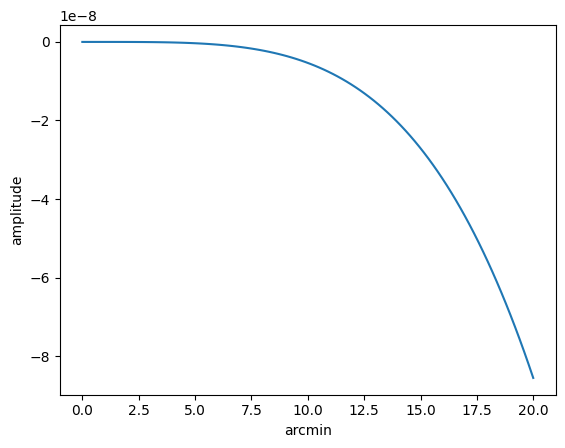

In [158]:
plt.plot(theta_arcmin,y[0])
plt.xlabel("arcmin")
plt.ylabel("amplitude")

In [144]:
y[1]

array([0.00000000e+00, 1.03399941e-09, 3.13696438e-09, 5.00289973e-09,
       6.90827545e-09, 8.95034473e-09, 1.12091469e-08, 1.37668741e-08,
       1.67108923e-08, 2.01341180e-08, 2.41347811e-08, 2.88160348e-08,
       3.42855421e-08, 4.06550782e-08, 4.80401614e-08, 5.65597142e-08,
       6.63357531e-08, 7.74931050e-08, 9.01591473e-08, 1.04463569e-07,
                  inf,            inf,            inf,            inf,
                  inf,            inf,            inf,            inf,
                  inf,            nan,            nan,            nan,
                  nan,            nan,            nan,            nan,
                  nan,            nan,            nan,            nan,
                  nan,            nan,            nan,            nan,
                  nan,            nan,            nan,            nan,
                  nan,            nan,            nan,            nan,
                  nan,            nan,            nan,            nan,
      